# Lab 07: Model Evaluation
## FIELDPROOF Dataset

**Student Name:** Nestor Villalobos  
**Course:** ITAI 1371  
**Lab:** Model Evaluation

## Introduction

In this lab, I evaluate machine learning model performance using the FIELDPROOF dataset. FIELDPROOF uses biometric and activity-based signals to verify real-world human activity. The goal of this lab is to measure how well a classification model performs using common evaluation metrics.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

In [7]:
data = {
    "heart_rate": [72, 85, 90, 60, 78, 88, 95, 70, 76, 82, 68, 91, 74, 86, 79],
    "body_temp": [98.6, 99.1, 100.2, 97.9, 98.7, 99.5, 100.5, 98.0, 98.4, 99.0, 98.1, 100.0, 98.3, 99.4, 98.8],
    "movement_score": [80, 65, 50, 90, 85, 55, 45, 88, 82, 70, 92, 48, 84, 60, 77],
    "work_duration": [6, 5, 4, 8, 7, 4, 3, 7, 6, 5, 8, 3, 7, 4, 6],
    "compliance": [1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1]
}

df = pd.DataFrame(data)
df

,heart_rate,body_temp,movement_score,work_duration,compliance
0,72,98.6,80,6,1
1,85,99.1,65,5,1
2,90,100.2,50,4,0
3,60,97.9,90,8,1
4,78,98.7,85,7,1
5,88,99.5,55,4,0
6,95,100.5,45,3,0
7,70,98.0,88,7,1
8,76,98.4,82,6,1
9,82,99.0,70,5,1


## Step 1: Prepare Features and Target

In [8]:
X = df.drop("compliance", axis=1)
y = df["compliance"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 10
Testing samples: 5


### Explanation
The dataset is split into training and testing sets so the model can learn from one portion of the data and be evaluated on unseen data.

## Step 2: Train the Classification Model

In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predicted labels:", y_pred)

Predicted labels: [1 0 1 1 0]


### Explanation
Logistic Regression is used because the target variable, compliance, is binary: 1 for compliant and 0 for non-compliant.

## Step 3: Evaluate the Model

In [10]:
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

Accuracy: 0.8

Confusion Matrix:
 [[2 1]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.67      1.00      0.80         2

    accuracy                           0.80         5
   macro avg       0.83      0.83      0.80         5
weighted avg       0.87      0.80      0.80         5



### Analysis
Accuracy shows the overall percentage of correct predictions. The confusion matrix helps compare correct and incorrect predictions, while the classification report provides precision, recall, and F1-score for a deeper evaluation.

## Step 4: Plot ROC Curve

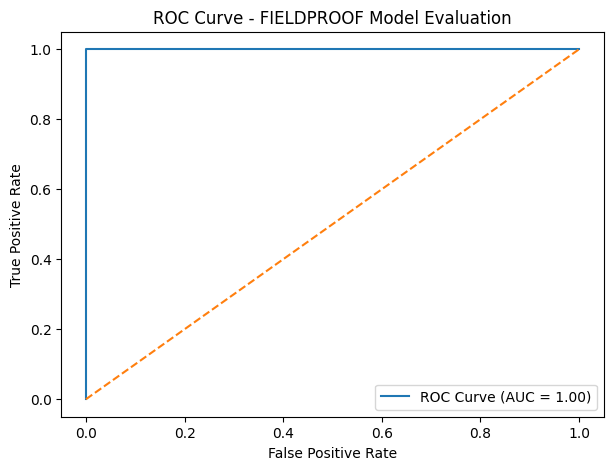

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - FIELDPROOF Model Evaluation")
plt.legend()
plt.show()

### ROC Curve Insight
The ROC curve shows how well the model separates compliant and non-compliant outcomes across threshold settings. A higher AUC indicates better model performance.

## Knowledge Check

**1. What does accuracy measure?**  
Accuracy measures the percentage of correct predictions made by the model.

**2. What does a confusion matrix show?**  
It shows true positives, true negatives, false positives, and false negatives.

**3. Why is the ROC curve useful?**  
It helps evaluate how well a classification model distinguishes between classes.

## Reflection

This lab helped me understand how to evaluate a machine learning model using several metrics instead of relying on accuracy alone. I learned that the confusion matrix, classification report, and ROC curve each provide a different perspective on model performance. Using the FIELDPROOF dataset made the activity more meaningful because it connected model evaluation to biometric and activity-based verification.